using Annie's paper, we updated the CO2 and CH4 emissions to "16.5 gCO2/kWh and 0.29 gCH4/kWh", leading to 28 gram per kWh of reservoir hydro emissions, as compared to the 16.1 gram per kWh of reservoir hydro ("electricity production, hydro, reservoir, non-alpine region", CA-QC) emissions from ecoinvent v3.11 cutoff, which has a "12.3 gCO2/kWh and 0.0213 gCH4/kWh".  
> scaled up CH4 by 14 times.

In [1]:
from __future__ import annotations
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

In [2]:
import sys
sys.path.append('../../utils/') 
from dpLCIA import * 

#### read in pkl

In [3]:
res_dir = Path.cwd() / "results_hydro_dpLCIA"

with open(res_dir / "results_rf_2030.pkl", "rb") as f:
    results_rf_2030 = pickle.load(f)

with open(res_dir / "results_agwp_2030.pkl", "rb") as f:
    results_agwp_2030 = pickle.load(f)

with open(res_dir / "results_rf_2050.pkl", "rb") as f:
    results_rf_2050 = pickle.load(f)

with open(res_dir / "results_agwp_2050.pkl", "rb") as f:
    results_agwp_2050 = pickle.load(f)

print("RF 2030 keys:", list(results_rf_2030.keys()))
print("AGWP 2030 keys:", list(results_agwp_2030.keys()))
print("RF 2050 keys:", list(results_rf_2050.keys()))
print("AGWP 2050 keys:", list(results_agwp_2050.keys()))


RF 2030 keys: [('SSP1-19', 2030), ('SSP5-85', 2030)]
AGWP 2030 keys: [('SSP1-19', 2030), ('SSP5-85', 2030)]
RF 2050 keys: [('SSP1-19', 2050), ('SSP5-85', 2050)]
AGWP 2050 keys: [('SSP1-19', 2050), ('SSP5-85', 2050)]


### plot 

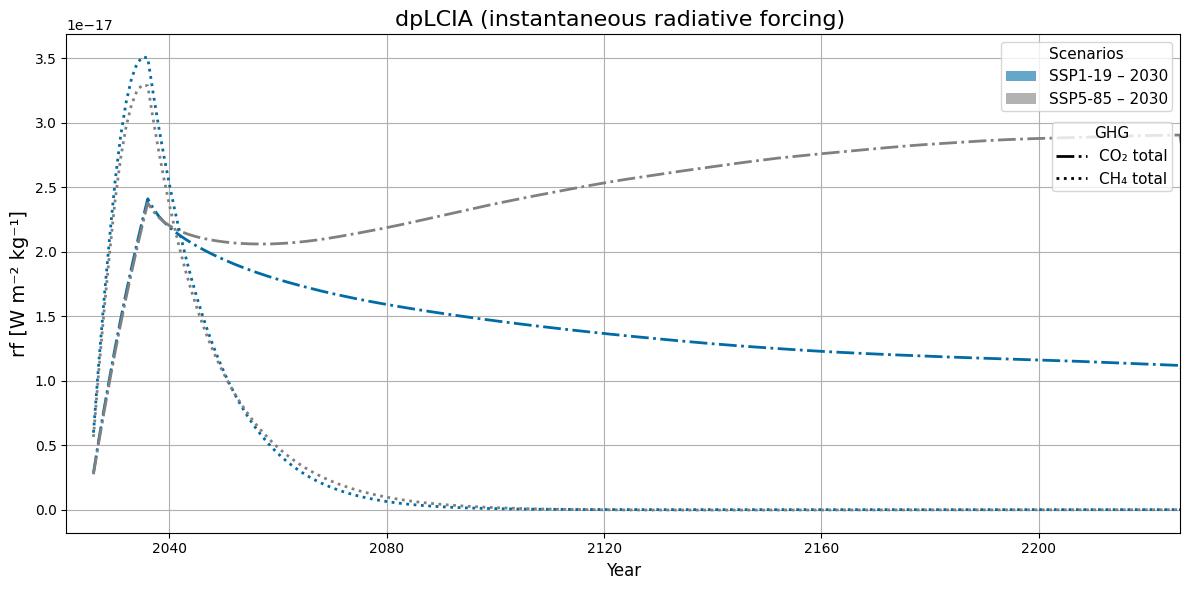

In [10]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf_2030,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= False,
    figsize  = (12, 6),
    x_limit=200,
    left_pad_years=5,
    save_path="fig_output/rf_co2total_ch4total_MY2030.png",
)

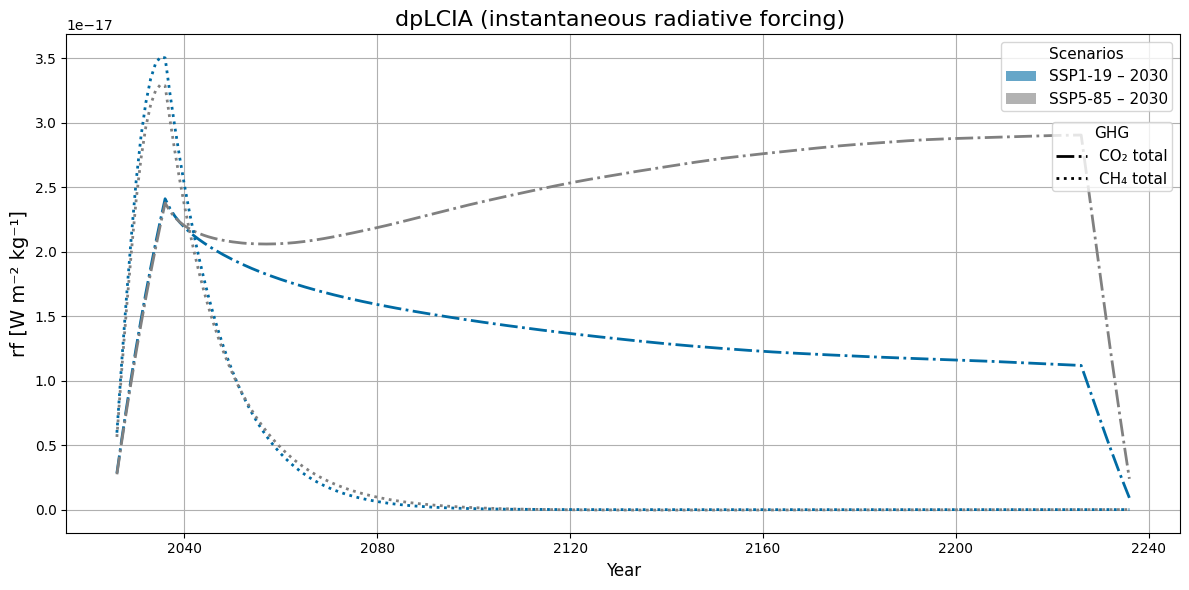

In [8]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf_2030,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= False,
    figsize  = (12, 6),
    #x_limit=200,
    #left_pad_years=5,
    #save_path="fig_output/rf_co2total_ch4total_MY2030.png",
)

### without prospective decay side (e.g., IPCC impulse response): 
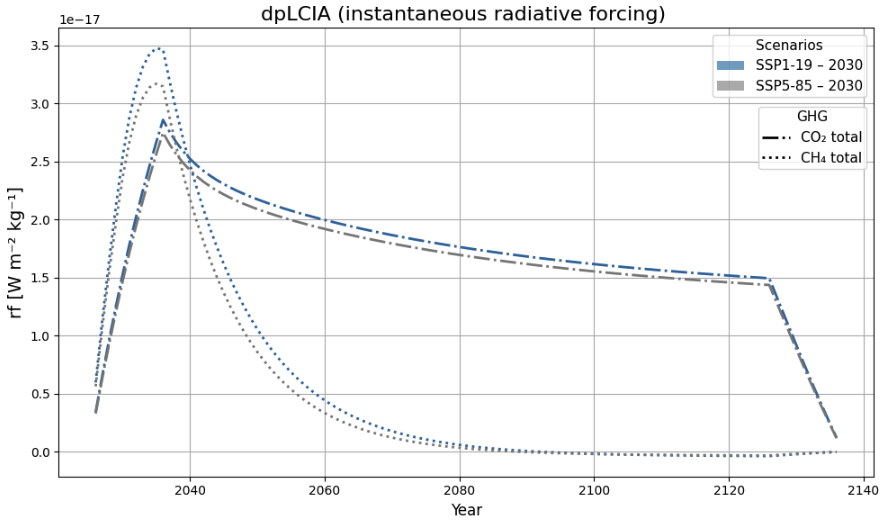

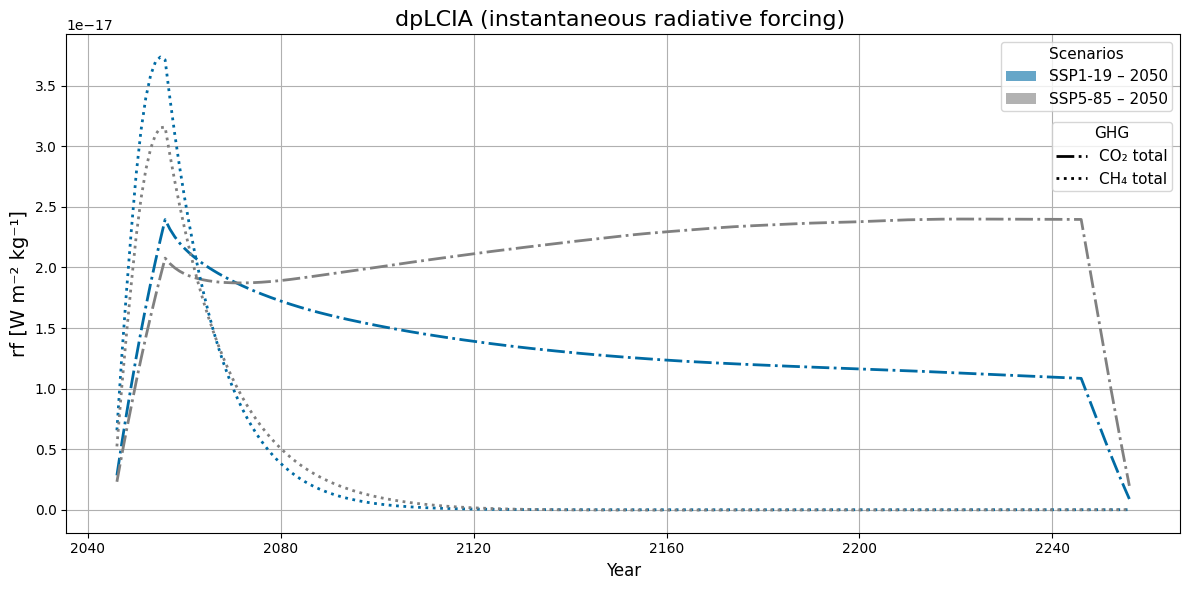

In [5]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf_2050,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= False,
    figsize  = (12, 6),
)

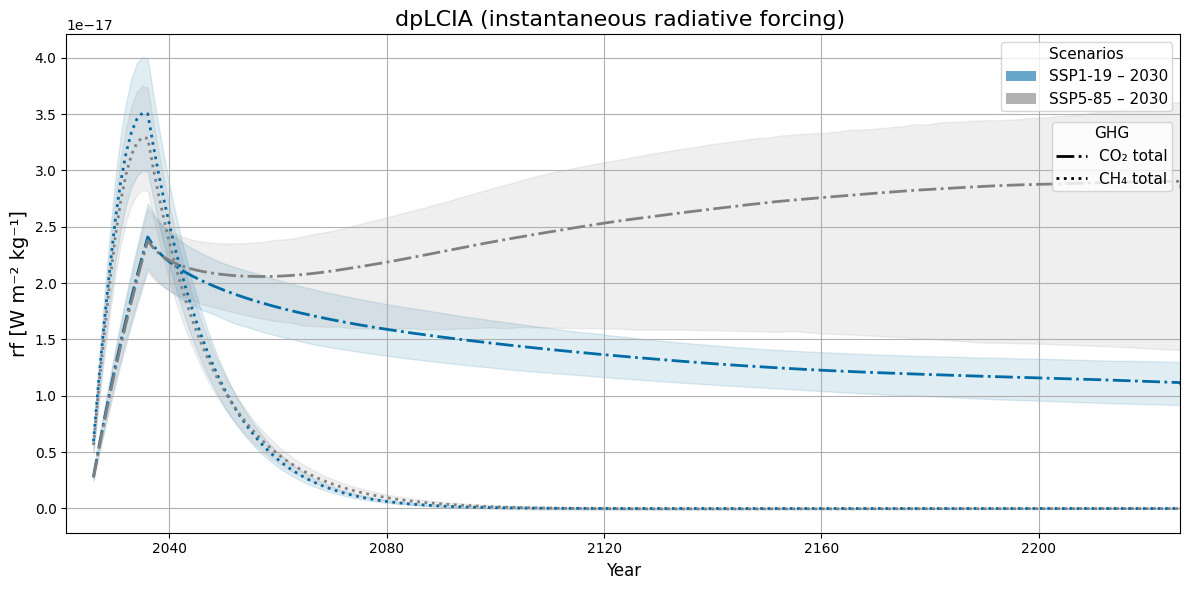

In [11]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf_2030,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= True,
    figsize  = (12, 6),
    x_limit=200,
    left_pad_years=5,
    save_path="fig_output/rf_co2total_ch4total_MY2030_wh-uncert.png",
)

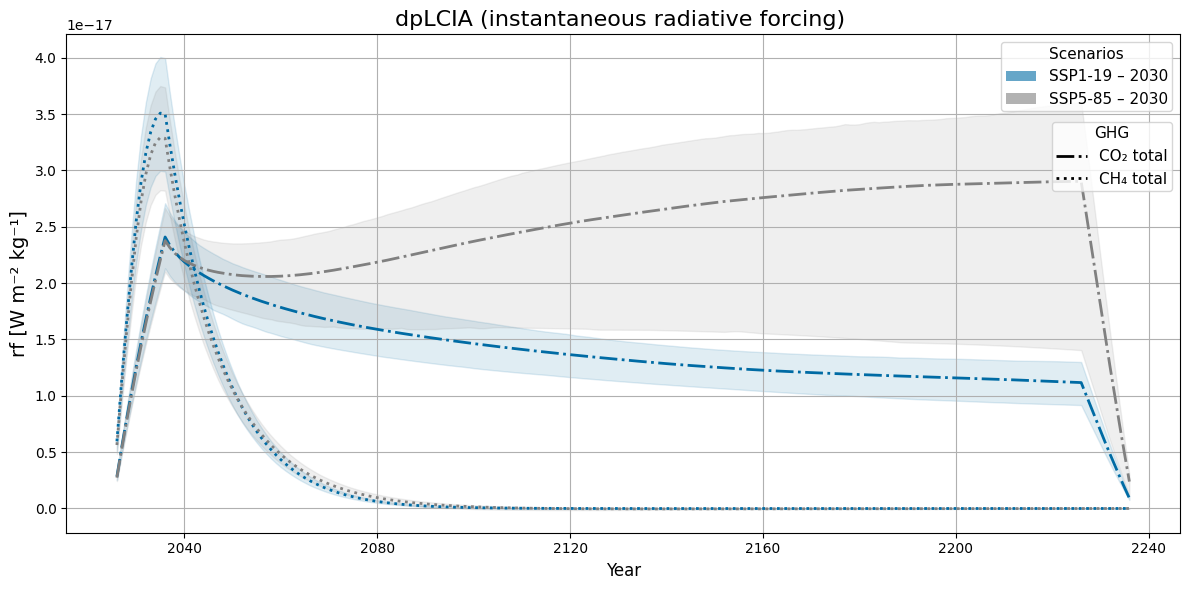

In [6]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf_2030,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= True,
    figsize  = (12, 6),
)

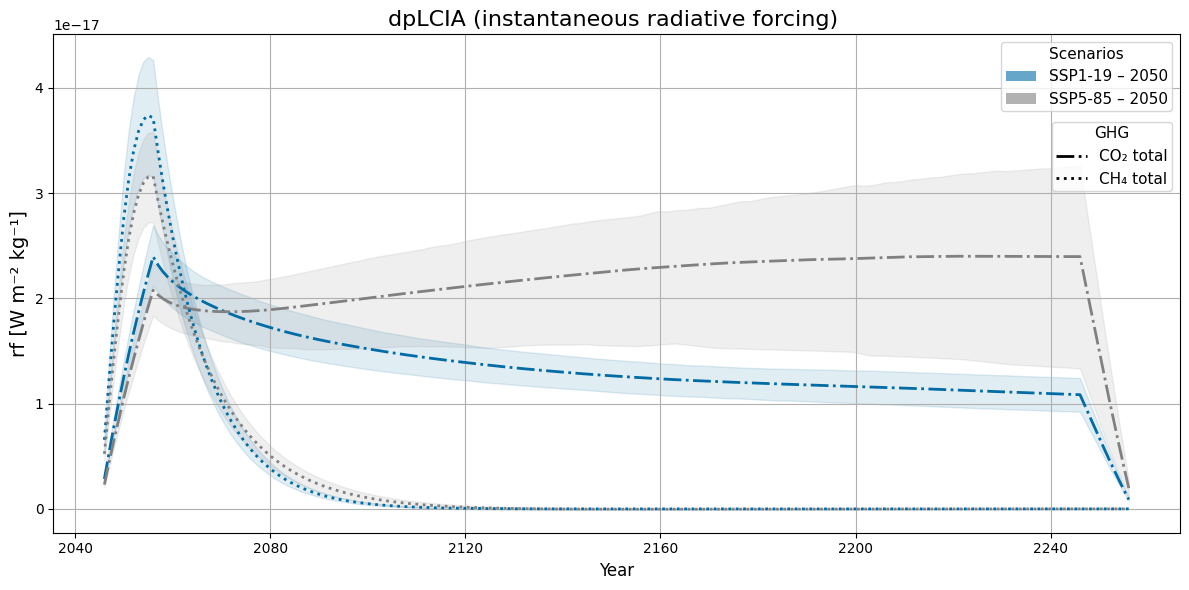

In [7]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_rf_2050,
    metric="rf",
    gases_to_plot = [  'co2_total', 'ch4_total' ] , #'co2_biogenic',   "ch4_non_fossil"], #
    plot_uncertainty= True,
    figsize  = (12, 6),
)

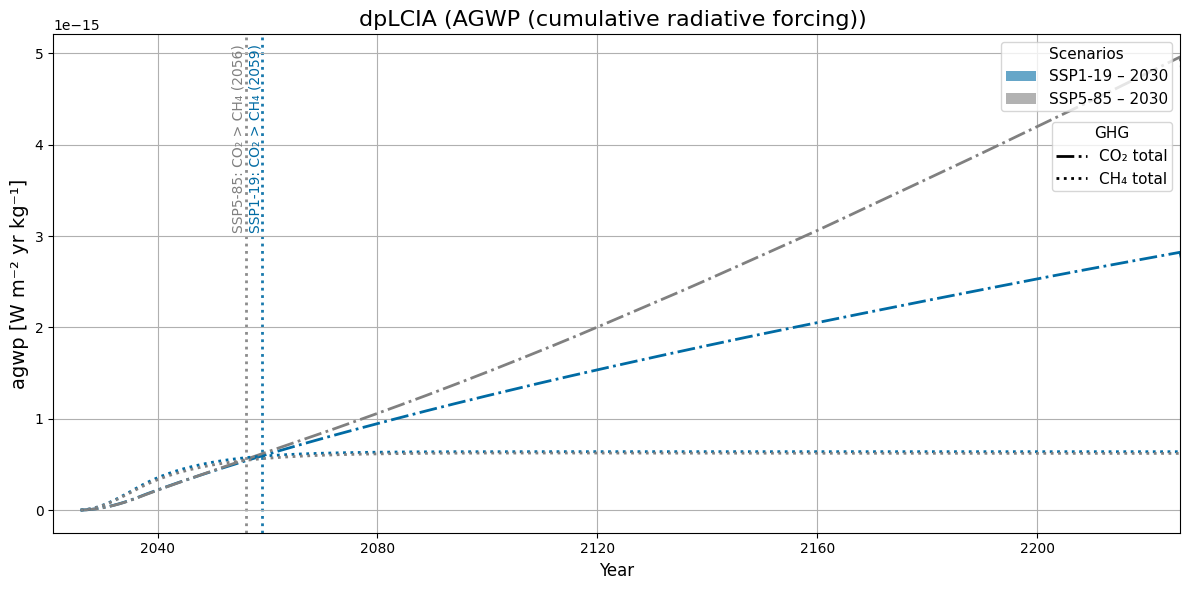

In [12]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_agwp_2030,
    metric="agwp",
    gases_to_plot = [  'co2_total', 'ch4_total' ] ,
    plot_uncertainty= False, 
    figsize  = (12, 6),
    x_limit=200,
    left_pad_years=5,
    save_path="fig_output/agwp_co2total_ch4total_MY2030.png",

)

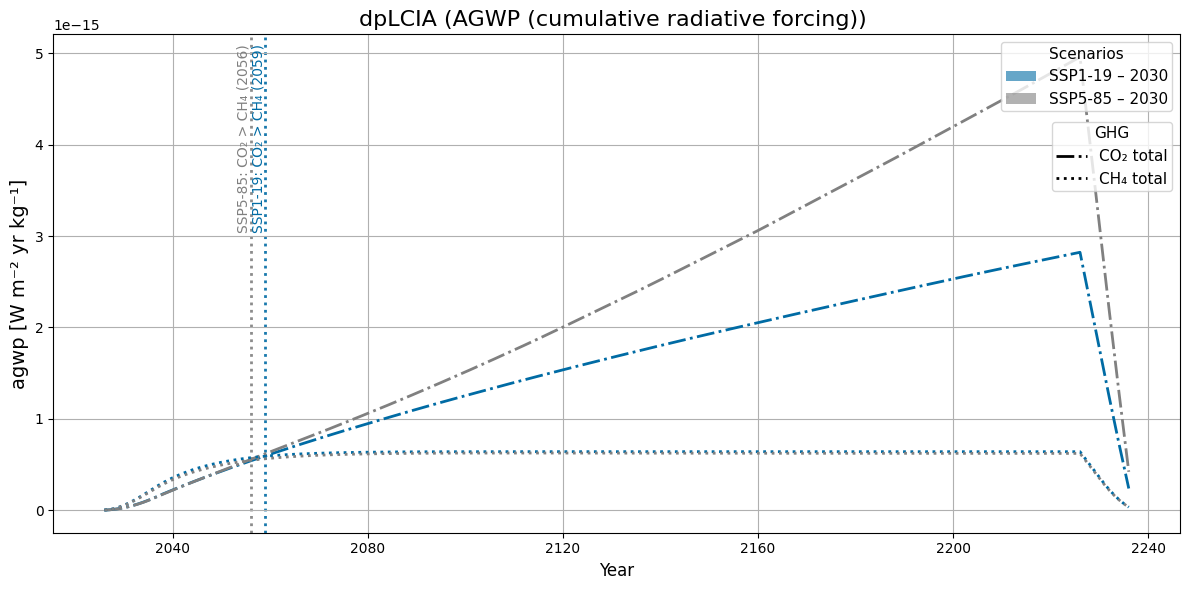

In [13]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_agwp_2030,
    metric="agwp",
    gases_to_plot = [  'co2_total', 'ch4_total' ] ,
    plot_uncertainty= False, 
    figsize  = (12, 6),
    #x_limit=200,
    #left_pad_years=5,
    #save_path="fig_output/agwp_co2total_ch4total_MY2030.png",

)

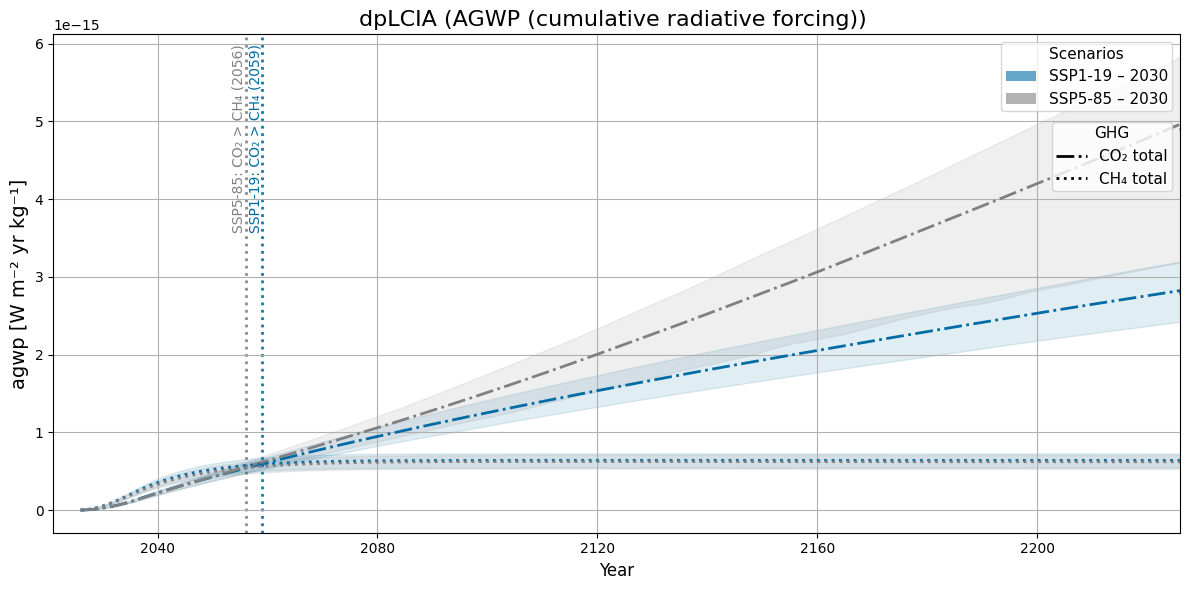

In [14]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_agwp_2030,
    metric="agwp",
    gases_to_plot = [  'co2_total', 'ch4_total' ] ,
    plot_uncertainty= True, 
    figsize  = (12, 6),
    x_limit=200,
    left_pad_years=5,
    save_path="fig_output/agwp_co2total_ch4total_MY2030_wh-uncert.png",

)

#### with the old metric (IPCC impulse response function): 
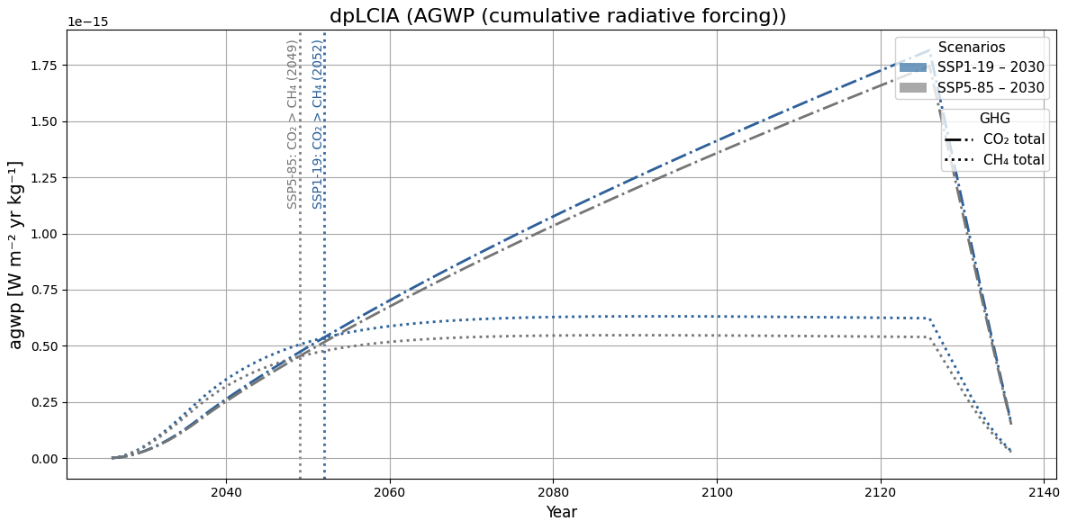

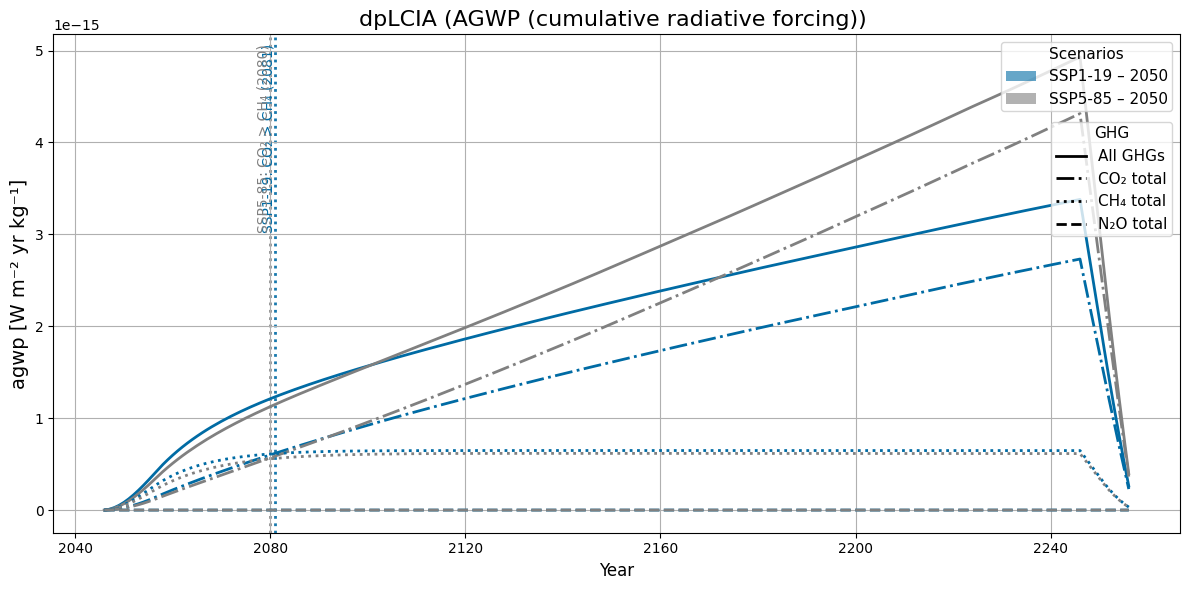

In [9]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results_agwp_2050,
    metric="agwp",
    #gases_to_plot = [  'co2_total', 'ch4_total' ] ,
    plot_uncertainty= False, 
    figsize  = (12, 6),
)

### single gas sub-cat, w/h uncertainty 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


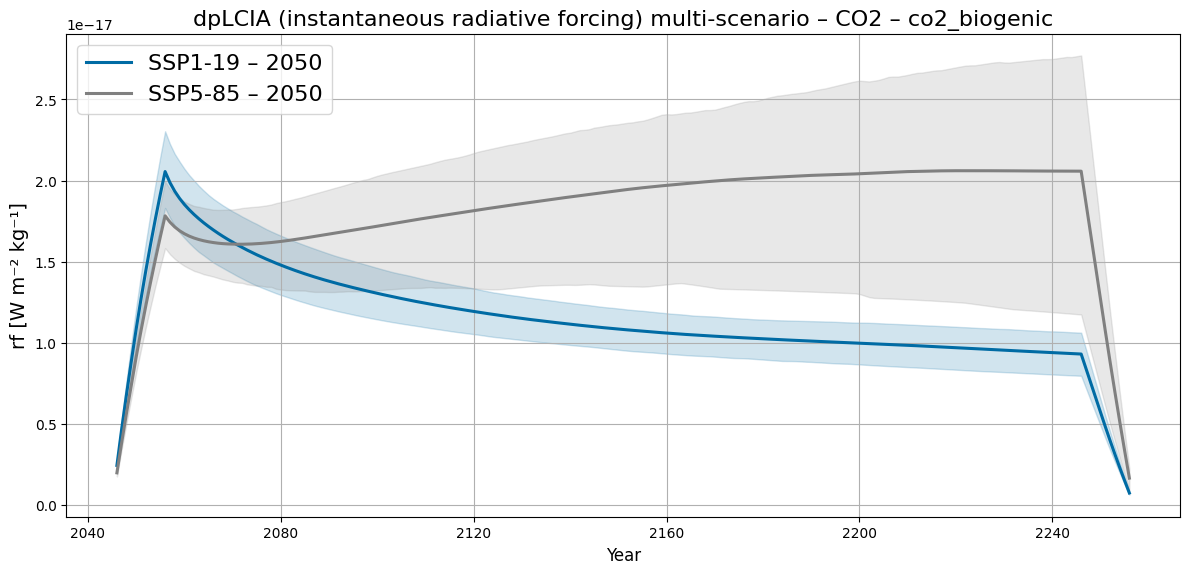

In [12]:
plot_multi_scenario_bands(
    results = results_rf_2050,
    metric = 'rf', 
    gas_to_plot = "CO2",
    subcat = "co2_biogenic") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


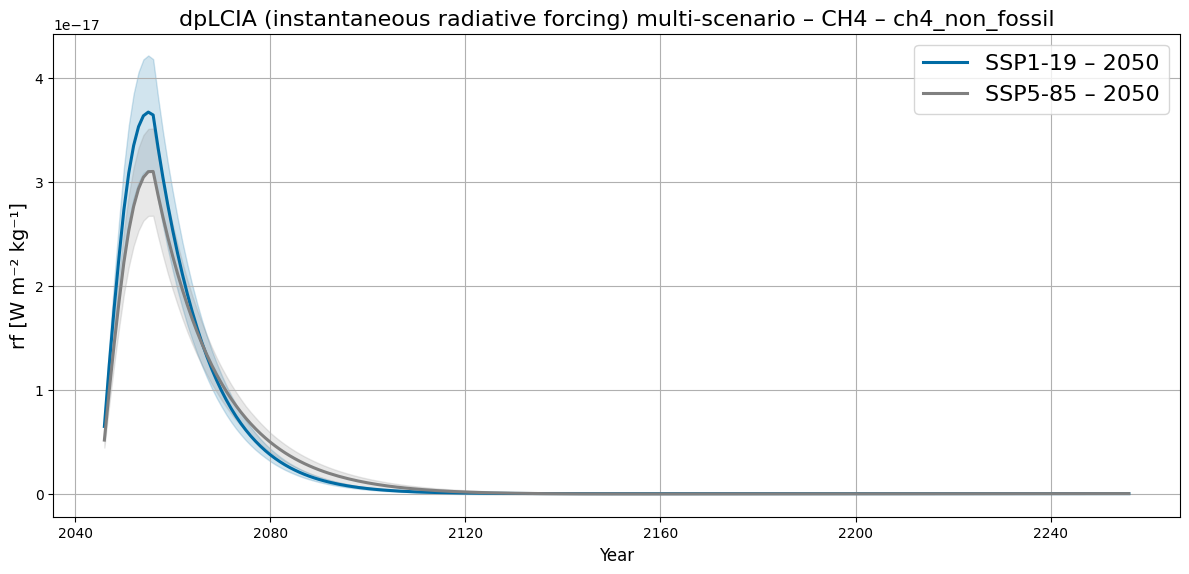

In [13]:
plot_multi_scenario_bands(
    results = results_rf_2050,
    metric = 'rf', 
    gas_to_plot = "CH4",
    subcat = "ch4_non_fossil") 